# 4.5 Parameter Estimation Nonlinear Equations

In [9]:
using LinearSolve
using NonlinearSolve
using CairoMakie
using Optimization
using Optimisers
using OptimizationOptimisers
using ForwardDiff

Consider the system of two nonlinear equations below

\begin{align}
y&= x^2 + b\\
y&=3\cos(x)
\end{align}

\begin{align}
u(x,y)&= x^2 -y+ b=0\\
v(x,y)&=3\cos(x)-y=0
\end{align}

The solution of this set of equations changes with $b$.  Let's plot the function to see how they look like

For this problem, it is easy and you can write $y$ in terms of $x$.  In general, you cannot do this for more complex problem.  A more general way of plotting the relationship between $x$ and $y$  is to use the `contour` function in Julia

In [10]:
function uandv(x,y,b)
    return [x^2-y+b,3*cos(x)-y]
end

xrange=0:0.02:3;
yrange=-2:0.02:5;
functionToPlot_01 = [uandv(x,y,1) for x in xrange, y in yrange];
functionToPlot_02 = [uandv(x,y,1.5) for x in xrange, y in yrange];
functionToPlot_03 = [uandv(x,y,2.0) for x in xrange, y in yrange];
functionToPlot_04 = [uandv(x,y,2.5) for x in xrange, y in yrange];


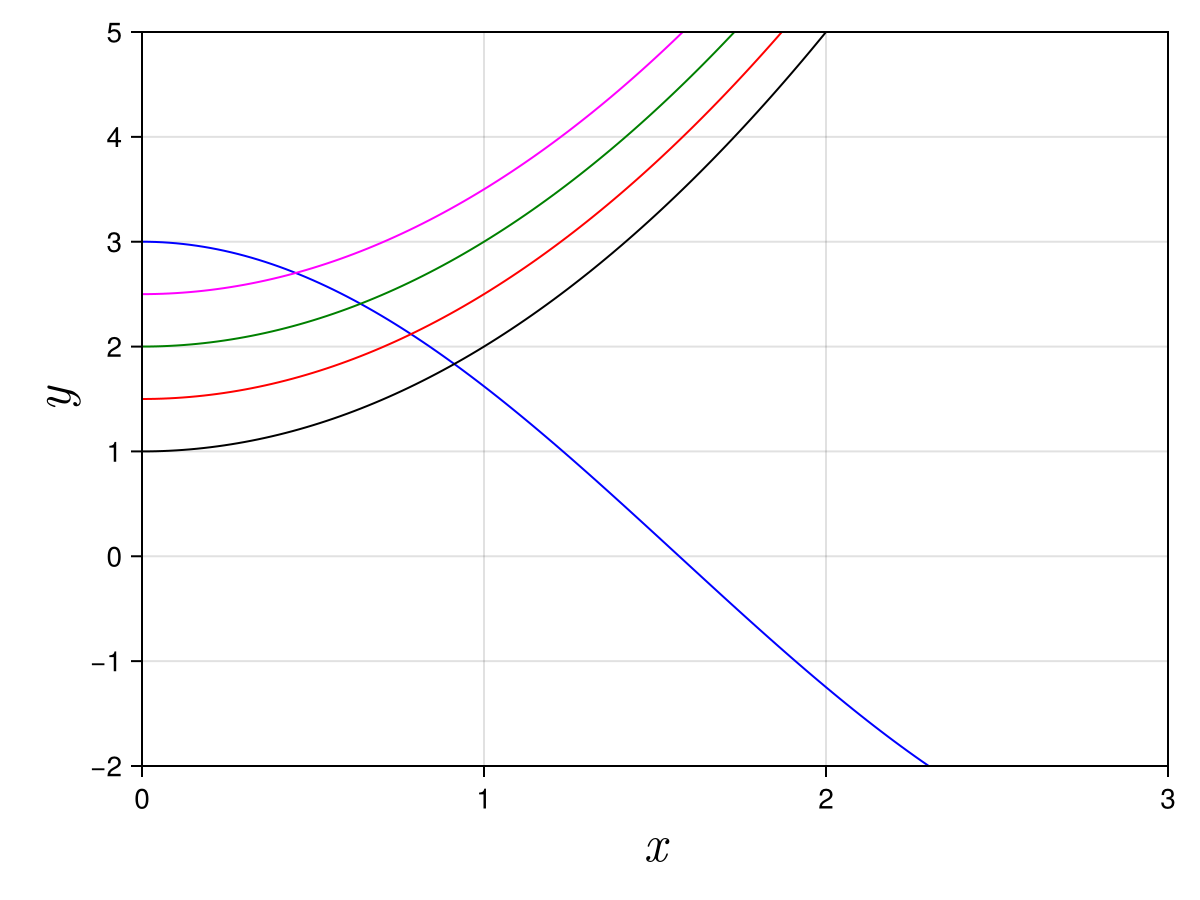

CairoMakie.Screen{IMAGE}


In [17]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y",
    xlabelsize = 25, 
    ylabelsize = 25,
    limits=(0,3.0,-2.0,5.0))

contour!(ax,xrange,yrange,getindex.(functionToPlot_01,2);  levels = [0.0],color=:blue, label=L"v(x,y)")
contour!(ax,xrange,yrange,getindex.(functionToPlot_01,1);  levels = [0.0],color=:black, label=L"u(x,y) b=1.0")
contour!(ax,xrange,yrange,getindex.(functionToPlot_02,1);  levels = [0.0],color=:red, label=L"u(x,y) b=1.5")
contour!(ax,xrange,yrange,getindex.(functionToPlot_03,1);  levels = [0.0],color=:green, label=L"u(x,y) b=2.0")
contour!(ax,xrange,yrange,getindex.(functionToPlot_04,1);  levels = [0.0],color=:magenta, label=L"u(x,y) b=2.5")

save("../figures/04p05ParameterEstimationsNonlinearProblems01.svg",fig)

display(fig)

The $v(x,y)$ function does not depend on $b$ but the $u(x,y)$ function changes with $b$.  As you can see, the $x$ value of the  intersection between  $u(x,y)$ and $v(x,y)$  changes with $b$. We would like to find the value of $b$ where the value of the $x$ intercept is 0.6.

We will first define the functions that we want to solve

\begin{align}
f_1(x_1,x_2)&= x_1^2 -x_2+ b=0\\
f_2(x_1,x_2)&=3\cos(x_1)-x_2=0
\end{align}

Note that for this problem, I will interchangeably use $u(x,y)$ and $v(x,y)$ with $f_1(x_1,x_2)$ and $f_2(x_1,x_2)$ respectively.

In [38]:
function FunctionToSolve(x,p)
    func=[x[1]^2-x[2]+p[1],3*cos(x[1])-x[2]]
    return func
end

FunctionToSolve (generic function with 1 method)

We will use Julia's  `NonlinearSolve` library to solve the set of two equations so that we can get an idea of how the $x$ intercept changes with $b$

In [39]:
bvec=1.0:0.1:2.5
xvec=zeros(length(bvec))
for i=1:length(bvec)    
    prob = NonlinearProblem(FunctionToSolve,[1.0,1.0],[bvec[i]])
    sol = NonlinearSolve.solve(prob)
    xvec[i]=sol.u[1]
end

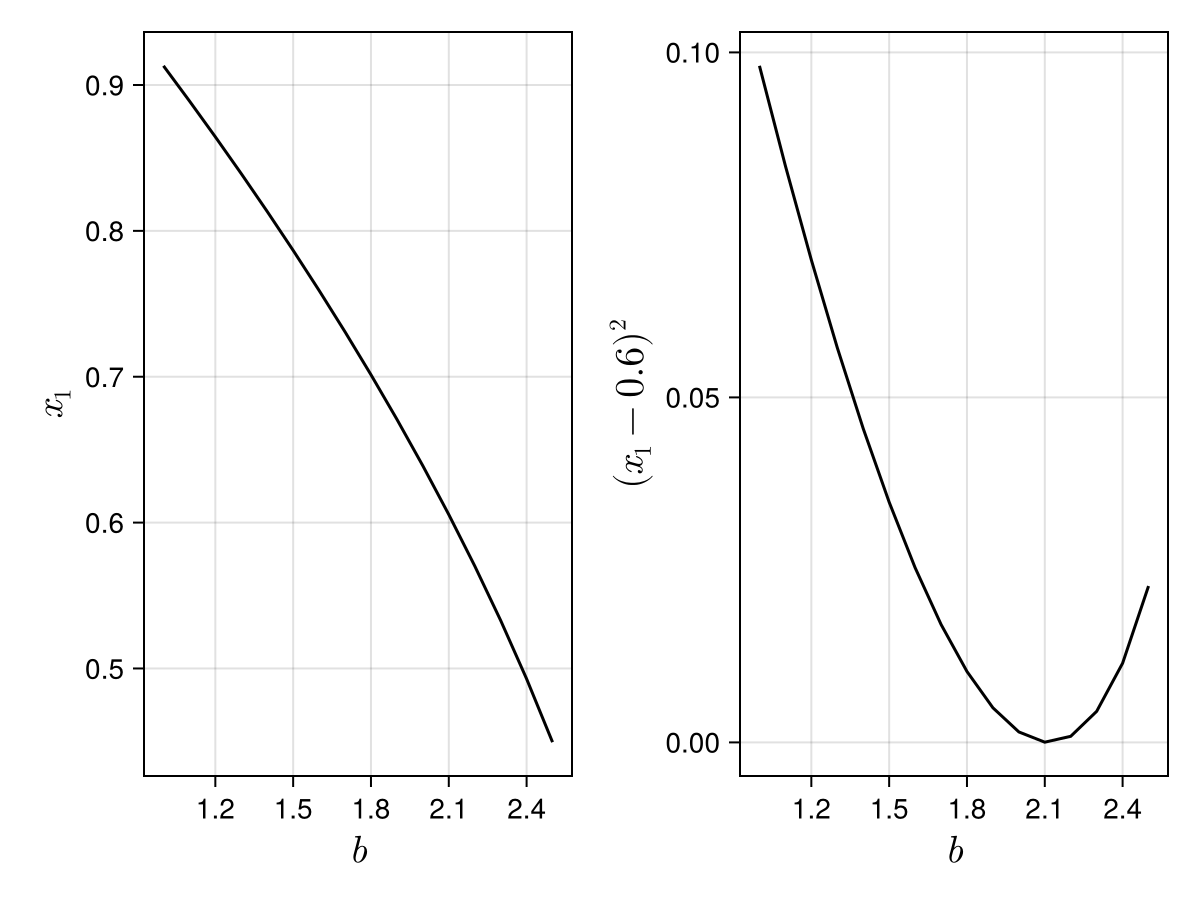

CairoMakie.Screen{IMAGE}


In [40]:
fig = Figure() #set up a figure
ax1 = Axis(fig[1, 1], 
xlabelsize=20,
ylabelsize=20,
xlabel = L"b", ylabel = L"x_1") #Define axis in the figure
lines!(ax1,bvec,xvec;color=:black)
ax2 = Axis(fig[1, 2],
xlabelsize=20,
ylabelsize=20,
xlabel = L"b", ylabel = L"(x_1-0.6)^2") #Define axis in the figure
lines!(ax2,bvec,(xvec.-0.6).^2;color=:black)
save("../figures/04p05ParameterEstimationsNonlinearProblems02.svg",fig)
display(fig)

What we have here is a constrained optimisation problem.  We would like to minimise the loss function 

$S=(x_1(b)-0.6)^2$

(remember that $x_1$ is a function of $b$ because everytime we change $b$, the value of $x_1$ will change) subject to the constraint

\begin{align}
x_1^2 -x_2+ b=0\\
3\cos(x_1)-x_2=0
\end{align}



---

The loss function is when the value of the $x$ value of the intercept is 0.6.  So we will let the loss function be $(x_1-0.6)^2$.  Note that to evaluate the `loss()` function, we need to solve a nonlinear set of equations  to find the value of $x_1$.  We need to do this every time $b$ changes.   There is a relationship between $x_1$ and $b$.  We  cannot explicitly write it down, we need to calculate it by solving a set of equations. 

In [41]:
function loss(b,x)
    prob = NonlinearProblem(FunctionToSolve,x,b)
    sol = NonlinearSolve.solve(prob)
    return sum((sol.u[1]-0.6).^2) #trying to minimise x_1=0.6
end

loss (generic function with 1 method)

Check that the loss function makes sense.  

In [42]:
loss([1.3],[1.0,1.0])

0.05720665085172735

Check if the derivative makes sense

In [ ]:
f=(b)->loss(b,[1.0,1.0])
ForwardDiff.gradient(f,[1.3])[1]

-0.12232214053335448

Use "manual" gradient descent to find the value of $b$ that minimizes the loss function

In [44]:
bguess=1.0
α=0.1
for i=1:5000
    bguess-=α*ForwardDiff.gradient(f,[bguess])[1]
end
bguess
    

2.1160068447290263

Using the SciML library in Julia to find the optimum value of $b$.

In [36]:
function callback(state, l)
    push!(losses, l)
    if length(losses) % 50 == 0
        println("Current loss after $(length(losses)) iterations: $(losses[end])")
    end
    return false
end

callback (generic function with 1 method)

In [37]:
losses = Float64[]
optf = OptimizationFunction(loss,AutoForwardDiff())
optprob = OptimizationProblem(optf,[1.2],[1.0,1.0])
sol=Optimization.solve(optprob,Adam(0.1f0),maxiters=200,callback=callback)

Current loss after 50 iterations: 0.00023822612962153098
Current loss after 100 iterations: 1.5898255572425418e-6
Current loss after 150 iterations: 2.6292564339282386e-9
Current loss after 200 iterations: 1.8148137140683545e-11


retcode: Default
u: 1-element Vector{Float64}:
 2.1160055997864857

The value of $b$ where $x_1=0.6$ is 2.11600